# 5. Fantastic Charts: From Zero to Advanced

A quick-reference gallery progressing from the simplest possible chart to fully interactive, animated, and hierarchical visualisations. Every section is self-contained, copy any code block, swap in your own data, and it will work.

All examples use the **Palmer Penguins** dataset (always available) or the **Kaggle Survey 2020** dataset (run notebook 3 first to generate `data/kaggle_survey.csv`).

<a id="appendix"></a>

## Quick-Reference Appendix

Click any link to jump to that chart type.

- [A · Setup & Data Loading](#setup)

#### Matplotlib: Static, Full Control
- [B1 · Minimal Line Chart](#b1-line)
- [B2 · Scatter Plot with Colour Encoding](#b2-scatter)
- [B3 · Bar Chart with Value Labels](#b3-bar)
- [B4 · Histogram with Overlapping Groups](#b4-hist)
- [B5 · Subplots Grid](#b5-subplots)
- [B6 · Annotations & Publication Styling](#b6-style)

#### Seaborn: Statistical, Concise
- [C1 · Scatter + Regression Line](#c1-scatter)
- [C2 · Distribution & KDE Curve](#c2-dist)
- [C3 · Violin + Strip Overlay](#c3-cat)
- [C4 · Correlation Heatmap](#c4-heatmap)
- [C5 · Pairplot](#c5-pair)
- [C6 · Multi-Panel FacetGrid](#c6-facet)

#### Plotly: Interactive, Web-Ready
- [D1 · Scatter with Hover Tooltips](#d1-scatter)
- [D2 · Grouped & Stacked Bar](#d2-bar)
- [D3 · Box & Violin with Hover](#d3-box)
- [D4 · 3D Scatter](#d4-3d)
- [D5 · Animated Bubble Chart](#d5-animate)
- [D6 · Sunburst: Hierarchy Chart](#d6-sunburst)
- [D7 · Parallel Coordinates](#d7-parallel)
- [D8 · Dropdown Menu (Graph Objects)](#d8-dropdown)
- [D9 · Export as Standalone HTML](#d9-save)

#### Kaggle Survey 2020 *(run Notebook 3 first)*
- [E1 · Horizontal Bar Chart](#e1-bar)
- [E2 · Stacked Bar by Category](#e2-stacked)
- [E3 · Choropleth World Map](#e3-choropleth)
- [E4 · Interactive Treemap](#e4-treemap)

---
<a id="setup"></a>

## A · Setup & Data Loading

Run these three cells once before using any section below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print("All libraries loaded.")

All libraries loaded.


In [2]:
# Palmer Penguins, used in sections B, C, and D
df = pd.read_csv("data/penguins_clean.csv")
print(f"Penguins: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Penguins: 333 rows, 7 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female


In [3]:
# Kaggle Survey 2020, used in section E only
# Run notebook 3 first if this file does not exist
import os

if os.path.exists("data/kaggle_survey.csv"):
    df_kaggle = pd.read_csv("data/kaggle_survey.csv")
    print(
        f"Kaggle data loaded: {df_kaggle.shape[0]} rows, {df_kaggle.shape[1]} columns"
    )
else:
    df_kaggle = None
    print("kaggle_survey.csv not found, run notebook 3 to generate it.")

Kaggle data loaded: 20036 rows, 19 columns


---

## B · Matplotlib

**Philosophy**: build from a `Figure` (canvas) and `Axes` (drawing area) using `fig, ax = plt.subplots()`. Every element is controlled manually, giving unlimited customisation.

<a id="b1-line"></a>

### B1 · Minimal Line Chart

The fewest possible lines to get something on screen, then the same idea with real data and labels.

[↑ Appendix](#appendix)

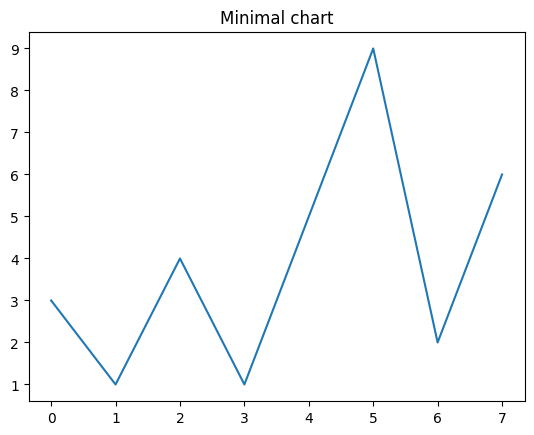

In [4]:
# Step 1, absolute minimum: pass a list of y-values
plt.plot([3, 1, 4, 1, 5, 9, 2, 6])
plt.title("Minimal chart")
plt.show()

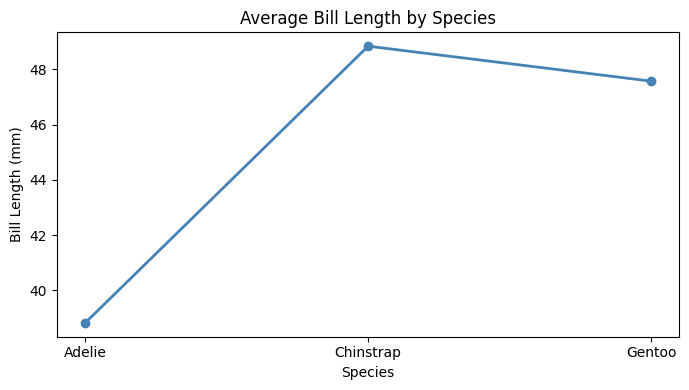

In [5]:
# Step 2, same idea with real data and labelled axes
avg_bill = df.groupby("species")["bill_length_mm"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(avg_bill.index, avg_bill.values, marker="o", linewidth=2, color="steelblue")
ax.set_title("Average Bill Length by Species")
ax.set_xlabel("Species")
ax.set_ylabel("Bill Length (mm)")
plt.tight_layout()
plt.show()
# Edit: marker='o' → try 's' (square), '^' (triangle), 'D' (diamond), '*' (star)
# Edit: color='steelblue' → any named colour or hex like '#E07B54'
# Edit: linewidth=2 → thicker (4) or thinner (1)

<a id="b2-scatter"></a>

### B2 · Scatter Plot with Colour Encoding

Loop over categories to create one scatter series per group, giving each its own legend entry and colour.

[↑ Appendix](#appendix)

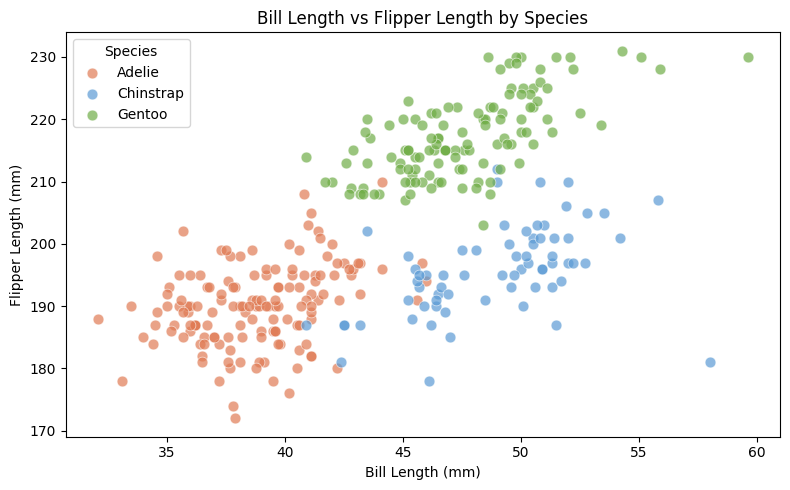

In [6]:
colours = {"Adelie": "#E07B54", "Chinstrap": "#5B9BD5", "Gentoo": "#70AD47"}

fig, ax = plt.subplots(figsize=(8, 5))
for species, colour in colours.items():
    mask = df["species"] == species
    ax.scatter(
        df.loc[mask, "bill_length_mm"],
        df.loc[mask, "flipper_length_mm"],
        c=colour,
        label=species,
        alpha=0.7,
        s=60,
        edgecolors="white",
        linewidths=0.5,
    )

ax.set_xlabel("Bill Length (mm)")
ax.set_ylabel("Flipper Length (mm)")
ax.set_title("Bill Length vs Flipper Length by Species")
ax.legend(title="Species")
plt.tight_layout()
plt.show()
# Edit: s=60 → point size (larger number = bigger dots)
# Edit: alpha=0.7 → transparency 0 (invisible) to 1 (solid)
# Edit: swap the two columns in ax.scatter() to change which axes they appear on

<a id="b3-bar"></a>

### B3 · Bar Chart with Value Labels

Add a number above each bar using a loop over `bars`. Remove the top and right spines for a cleaner look.

[↑ Appendix](#appendix)

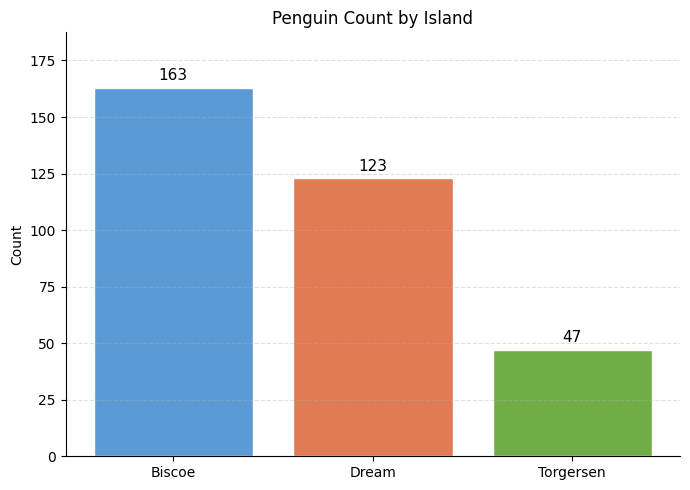

In [7]:
counts = df["island"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    counts.index,
    counts.values,
    color=["#5B9BD5", "#E07B54", "#70AD47"],
    edgecolor="white",
)

# Add count label above each bar
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(bar.get_height())),
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.set_title("Penguin Count by Island")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
# Edit: change ax.bar() to ax.barh() for horizontal bars (swap x/y arguments)
# Edit: color= list → any hex codes, one per bar
# Edit: edgecolor='white' → 'black' or 'none'

<a id="b4-hist"></a>

### B4 · Histogram with Overlapping Groups

Plot multiple histograms on the same axes with `alpha` transparency so all distributions stay visible.

[↑ Appendix](#appendix)

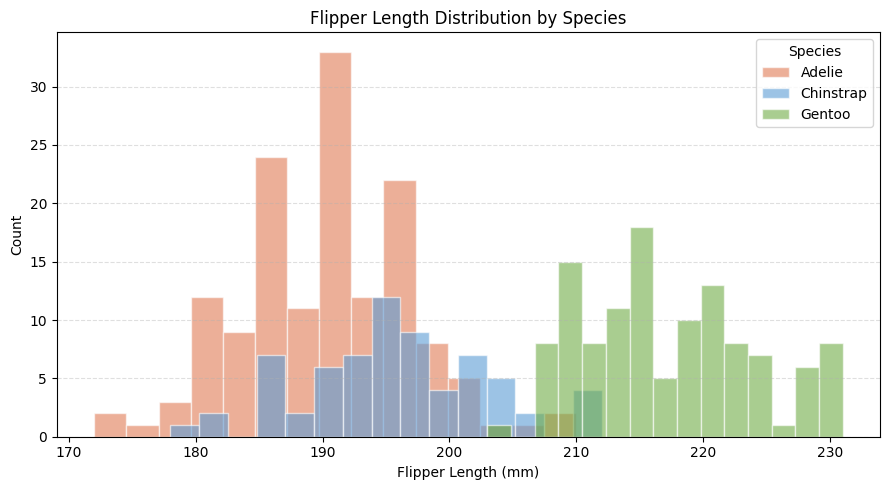

In [8]:
colours = {"Adelie": "#E07B54", "Chinstrap": "#5B9BD5", "Gentoo": "#70AD47"}

fig, ax = plt.subplots(figsize=(9, 5))
for species, colour in colours.items():
    ax.hist(
        df[df["species"] == species]["flipper_length_mm"],
        bins=15,
        alpha=0.6,
        color=colour,
        label=species,
        edgecolor="white",
    )

ax.set_title("Flipper Length Distribution by Species")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Count")
ax.legend(title="Species")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
# Edit: bins=15 → fewer bins (5) for a coarser view, more (40) for finer detail
# Edit: alpha=0.6 → lower makes overlap more transparent
# Edit: swap 'flipper_length_mm' for any numeric column

<a id="b5-subplots"></a>

### B5 · Subplots Grid

`plt.subplots(nrows, ncols)` returns a 2D array of Axes. Flatten it to loop over them cleanly.

[↑ Appendix](#appendix)

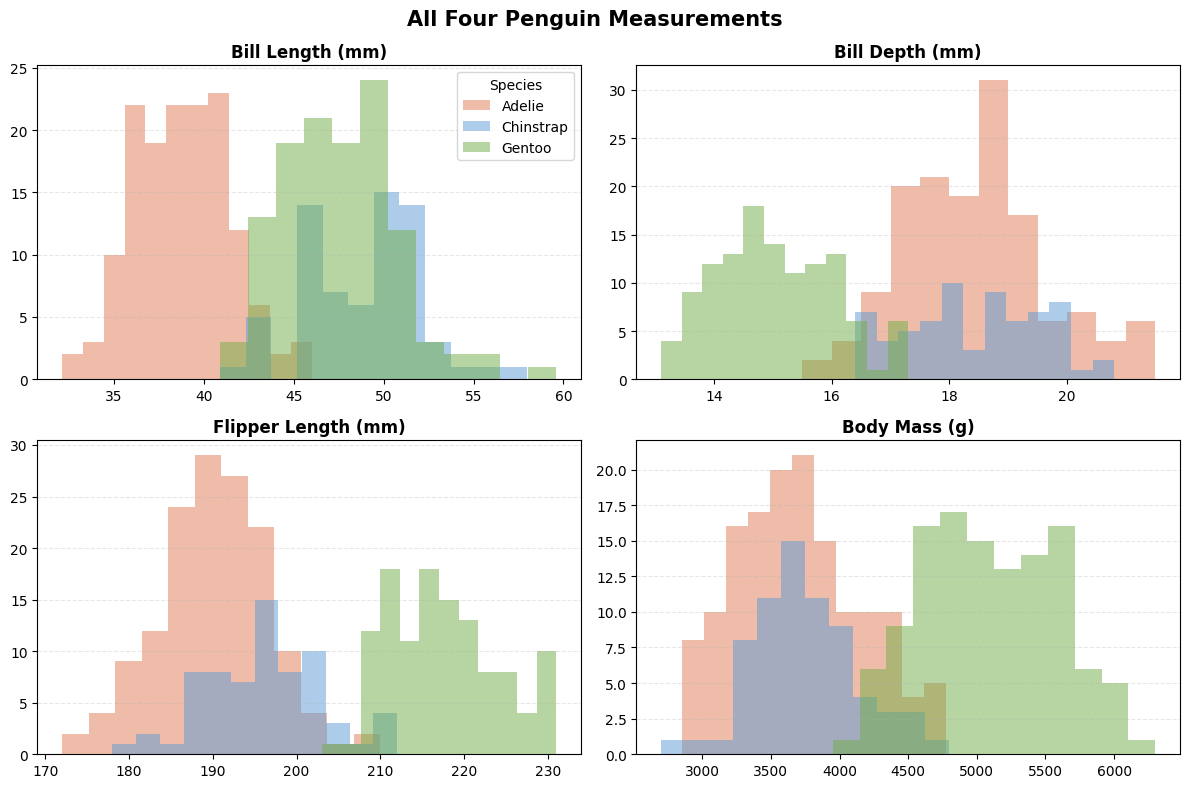

In [9]:
measurements = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
titles = ["Bill Length (mm)", "Bill Depth (mm)", "Flipper Length (mm)", "Body Mass (g)"]
colours = {"Adelie": "#E07B54", "Chinstrap": "#5B9BD5", "Gentoo": "#70AD47"}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()  # convert 2D array → 1D for easy looping

for ax, col, title in zip(axes, measurements, titles):
    for species, colour in colours.items():
        ax.hist(
            df[df["species"] == species][col],
            bins=12,
            alpha=0.5,
            color=colour,
            label=species,
        )
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].legend(title="Species")  # legend on top-left only to reduce clutter
fig.suptitle("All Four Penguin Measurements", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
# Edit: nrows=2, ncols=2 → try nrows=1, ncols=4 for a single wide row
# Edit: sharey=True in plt.subplots() to lock all y-axes to the same scale

<a id="b6-style"></a>

### B6 · Annotations & Publication Styling

Use `ax.annotate()` for arrow callouts and `plt.style.context()` to apply a theme without permanently changing global settings.

[↑ Appendix](#appendix)

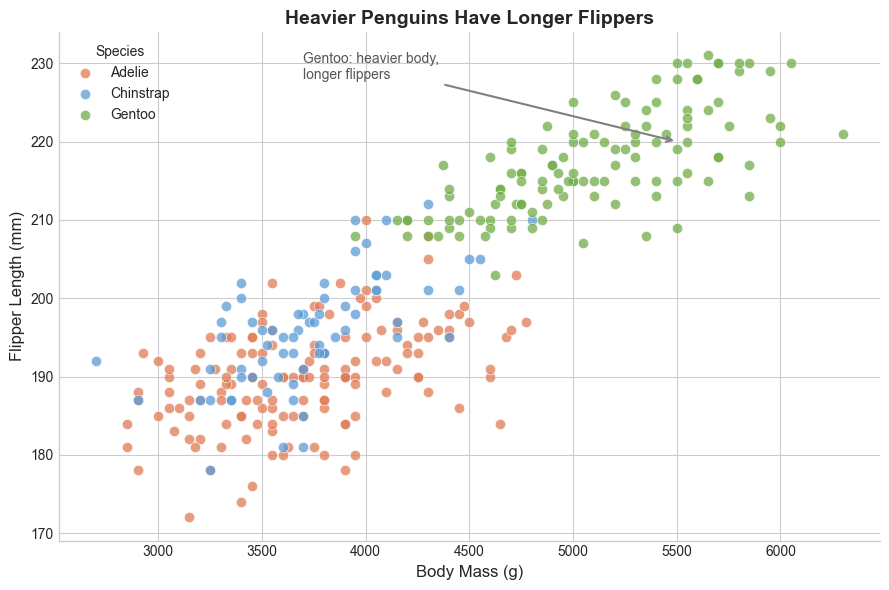

In [10]:
colours = {"Adelie": "#E07B54", "Chinstrap": "#5B9BD5", "Gentoo": "#70AD47"}

with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(9, 6))
    for species, colour in colours.items():
        mask = df["species"] == species
        ax.scatter(
            df.loc[mask, "body_mass_g"],
            df.loc[mask, "flipper_length_mm"],
            c=colour,
            label=species,
            alpha=0.75,
            s=55,
            edgecolors="white",
            linewidths=0.5,
        )

    # Arrow annotation pointing at the Gentoo cluster
    ax.annotate(
        "Gentoo: heavier body,\nlonger flippers",
        xy=(5500, 220),
        xytext=(3700, 228),
        arrowprops=dict(arrowstyle="->", color="grey", lw=1.5),
        fontsize=10,
        color="#555555",
    )

    ax.set_title(
        "Heavier Penguins Have Longer Flippers", fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Body Mass (g)", fontsize=12)
    ax.set_ylabel("Flipper Length (mm)", fontsize=12)
    ax.legend(title="Species")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
# Edit: replace 'seaborn-v0_8-whitegrid' → run plt.style.available to see all options
# Edit: move xy= (arrow tip) and xytext= (label position) to point at any data region
# Edit: arrowstyle='->' → try '-|>', 'fancy', 'simple'

---

## C · Seaborn

**Philosophy**: pass the whole DataFrame and column names as strings. Seaborn handles grouping, colours, legends, and statistical overlays automatically.

<a id="c1-scatter"></a>

### C1 · Scatter + Regression Line

`lmplot` adds a regression line and 95% confidence band with no extra calculation.

[↑ Appendix](#appendix)

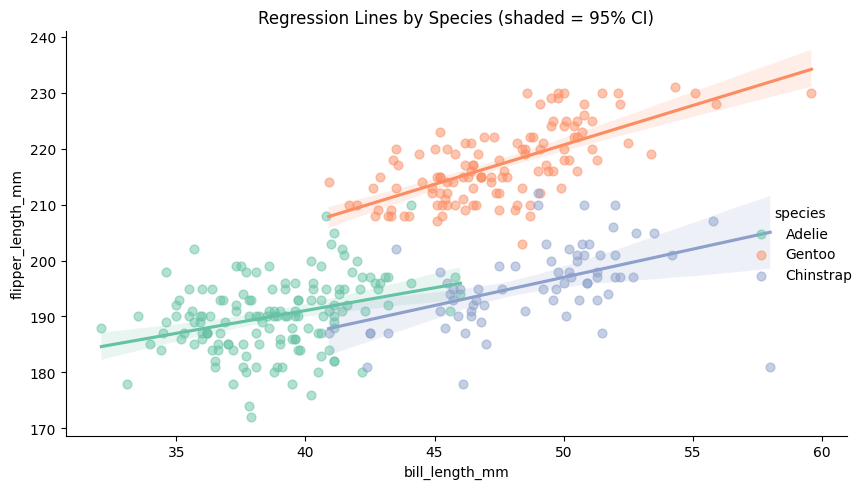

In [11]:
sns.lmplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    palette="Set2",
    height=5,
    aspect=1.5,
    scatter_kws={"alpha": 0.5, "s": 40},
)
plt.title("Regression Lines by Species (shaded = 95% CI)")
plt.tight_layout()
plt.show()
# Edit: ci=None to remove confidence bands, ci=99 for a wider 99% band
# Edit: swap x= and y= for any two numeric columns
# Edit: hue='island' to colour by a different categorical column

<a id="c2-dist"></a>

### C2 · Distribution & KDE Curve

`histplot` with `kde=True` overlays a smooth kernel density estimate on the histogram bars.

[↑ Appendix](#appendix)

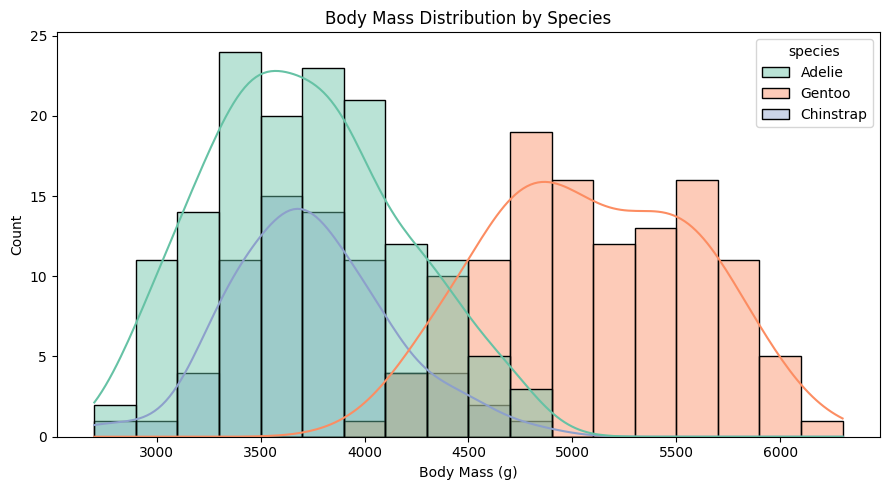

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df,
    x="body_mass_g",
    hue="species",
    kde=True,
    palette="Set2",
    alpha=0.45,
    bins=18,
    ax=ax,
)
ax.set_title("Body Mass Distribution by Species")
ax.set_xlabel("Body Mass (g)")
plt.tight_layout()
plt.show()
# Edit: kde=False to remove the smooth curve and show only bars
# Edit: x='body_mass_g' → any numeric column
# Edit: bins=18 → fewer for coarser bars, more for finer detail

<a id="c3-cat"></a>

### C3 · Violin + Strip Overlay

A violin shows the full distribution shape; a strip plot overlaid on top shows the actual data points.

[↑ Appendix](#appendix)

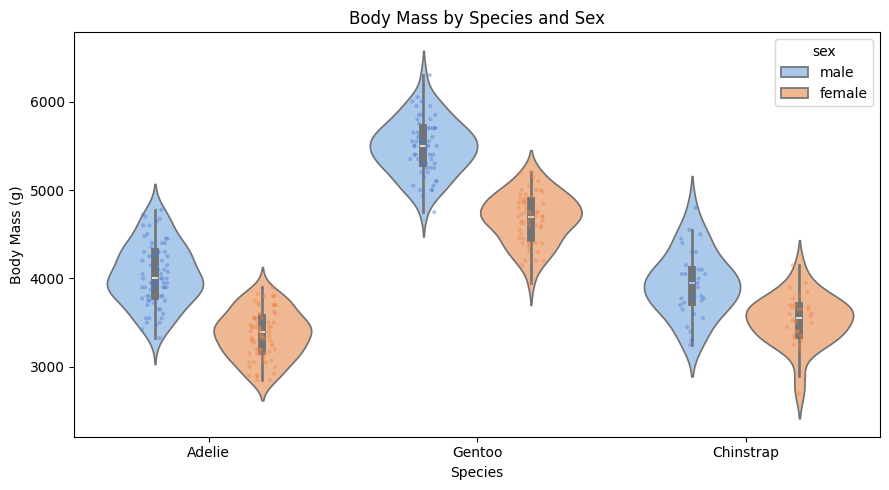

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

# Violin: distribution shape
sns.violinplot(
    data=df,
    x="species",
    y="body_mass_g",
    hue="sex",
    palette="pastel",
    inner="box",
    ax=ax,
)

# Strip: raw data points on top
sns.stripplot(
    data=df,
    x="species",
    y="body_mass_g",
    hue="sex",
    dodge=True,
    palette="muted",
    alpha=0.4,
    size=3,
    jitter=True,
    ax=ax,
    legend=False,
)

ax.set_title("Body Mass by Species and Sex")
ax.set_xlabel("Species")
ax.set_ylabel("Body Mass (g)")
plt.tight_layout()
plt.show()
# Edit: inner='box' → try 'quart', 'point', or None (no inner marks)
# Edit: remove the stripplot call for a cleaner look
# Edit: size=3 in stripplot → larger number for bigger points

<a id="c4-heatmap"></a>

### C4 · Correlation Heatmap

A mask hides the upper triangle (it is a mirror of the lower) to reduce visual clutter.

[↑ Appendix](#appendix)

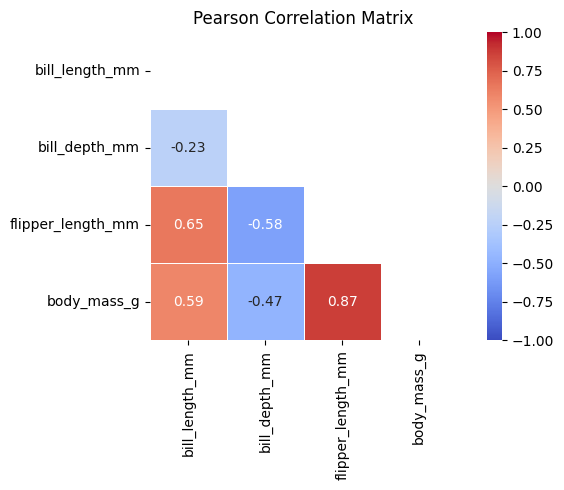

In [14]:
corr = df.select_dtypes("number").corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()
# Edit: cmap='coolwarm' → try 'Blues', 'RdYlGn', 'viridis'
# Edit: remove mask= to show the full symmetric matrix
# Edit: annot=False to hide the numbers inside each cell

<a id="c5-pair"></a>

### C5 · Pairplot

One command creates a full grid of scatter plots for every pair of numeric columns, with distributions on the diagonal. The fastest way to get an overview of a dataset.

[↑ Appendix](#appendix)

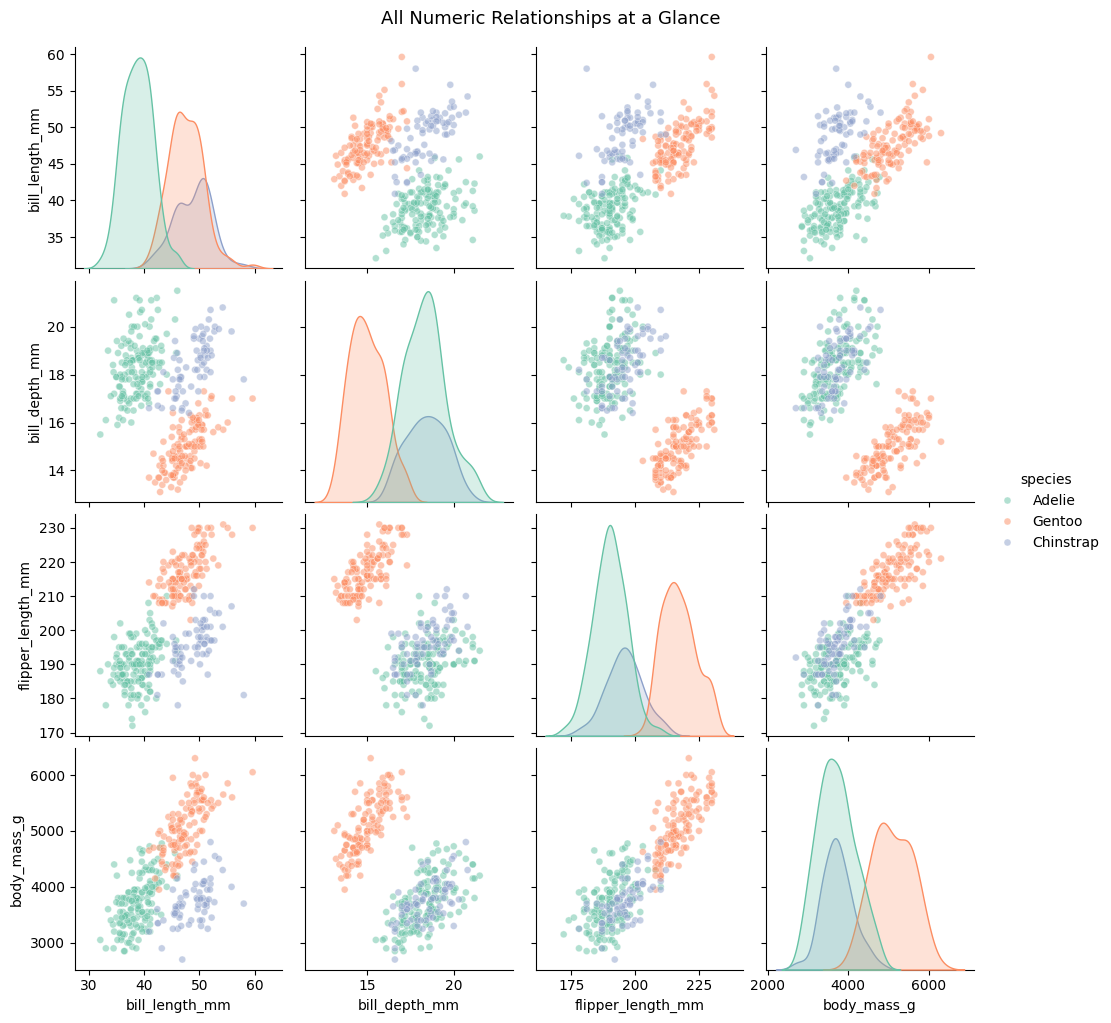

In [15]:
g = sns.pairplot(
    data=df,
    hue="species",
    palette="Set2",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 25},
)
g.fig.suptitle("All Numeric Relationships at a Glance", y=1.02, fontsize=13)
plt.show()
# Edit: diag_kind='kde' → 'hist' for histograms on the diagonal
# Edit: hue='sex' to colour by a different categorical column
# Edit: vars=['bill_length_mm','flipper_length_mm'] to limit which columns appear

<a id="c6-facet"></a>

### C6 · Multi-Panel FacetGrid

`catplot` automatically creates one subplot panel per category. Add `col=` for columns and `row=` for rows.

[↑ Appendix](#appendix)

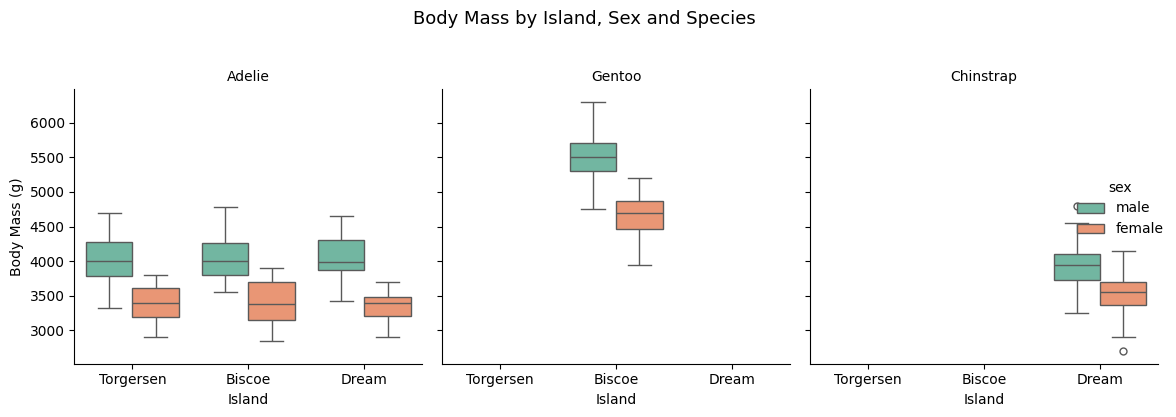

In [16]:
g = sns.catplot(
    data=df,
    x="island",
    y="body_mass_g",
    hue="sex",
    kind="box",
    col="species",
    palette="Set2",
    height=4,
    aspect=0.9,
)
g.set_axis_labels("Island", "Body Mass (g)")
g.set_titles("{col_name}")
g.fig.suptitle("Body Mass by Island, Sex and Species", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()
# Edit: kind='box' → try 'violin', 'strip', 'swarm', 'bar', 'point'
# Edit: add row='sex' to split into rows as well as columns
# Edit: col='island' and x='species' to flip the grouping

---

## D · Plotly

**Philosophy**: every chart is interactive by default, hover for tooltips, scroll to zoom, click legend entries to toggle groups. Use `plotly.express` (`px`) for most charts; drop down to `plotly.graph_objects` (`go`) only when you need fine-grained control.

<a id="d1-scatter"></a>

### D1 · Scatter with Hover Tooltips

The simplest Plotly chart. Every point is immediately hoverable, zoomable, and filterable via the legend.

[↑ Appendix](#appendix)

In [17]:
fig = px.scatter(
    df,
    x="bill_length_mm",
    y="flipper_length_mm",
    color="species",
    symbol="sex",
    hover_data=["island", "body_mass_g"],
    title="Bill Length vs Flipper Length, hover any point for details",
    labels={
        "bill_length_mm": "Bill Length (mm)",
        "flipper_length_mm": "Flipper Length (mm)",
    },
    template="plotly_white",
    width=750,
    height=500,
)
fig.show()
# Edit: hover_data= list → add any column names to show on hover
# Edit: template= → try 'plotly_dark', 'ggplot2', 'simple_white'
# Edit: remove symbol='sex' to use circles for all points

<a id="d2-bar"></a>

### D2 · Grouped & Stacked Bar

Change one argument (`barmode`) to switch between grouped bars (compare absolute values) and stacked bars (compare proportions).

[↑ Appendix](#appendix)

In [18]:
counts = df.groupby(["island", "species"]).size().reset_index(name="count")

fig = px.bar(
    counts,
    x="island",
    y="count",
    color="species",
    barmode="group",  # change to 'stack' for stacked bars
    title="Penguins per Island and Species",
    labels={"count": "Count", "island": "Island"},
    color_discrete_map={
        "Adelie": "#E07B54",
        "Chinstrap": "#5B9BD5",
        "Gentoo": "#70AD47",
    },
    template="plotly_white",
    width=700,
    height=450,
)
fig.update_layout(legend_title="Species")
fig.show()
# Edit: barmode='group' → 'stack' to show proportions
# Edit: color_discrete_map= → replace hex codes with your own colours
# Edit: swap x='island' with x='species' to flip the grouping axis

<a id="d3-box"></a>

### D3 · Box & Violin with Hover

`box=True` embeds a box plot inside the violin. Hover over any part to see exact statistics.

[↑ Appendix](#appendix)

In [19]:
fig = px.violin(
    df,
    x="species",
    y="body_mass_g",
    color="sex",
    box=True,
    points="outliers",
    title="Body Mass, violin + embedded box + outlier points",
    labels={"body_mass_g": "Body Mass (g)", "species": "Species"},
    template="plotly_white",
    width=750,
    height=500,
)
fig.show()
# Edit: box=False to hide the inner box plot
# Edit: points='outliers' → 'all' to show every data point, False to show none
# Edit: swap px.violin for px.box to get a plain interactive box plot

<a id="d4-3d"></a>

### D4 · 3D Scatter

Adds a third axis. Click and drag the chart to rotate it in 3D.

[↑ Appendix](#appendix)

In [20]:
fig = px.scatter_3d(
    df,
    x="bill_length_mm",
    y="bill_depth_mm",
    z="flipper_length_mm",
    color="species",
    symbol="sex",
    opacity=0.75,
    title="Three Dimensions, click and drag to rotate",
    labels={
        "bill_length_mm": "Bill Length",
        "bill_depth_mm": "Bill Depth",
        "flipper_length_mm": "Flipper Length",
    },
    template="plotly_white",
    width=800,
    height=600,
)
fig.update_traces(marker_size=4)
fig.show()
# Edit: x=, y=, z= → any three numeric columns
# Edit: opacity=0.75 → lower to see overlapping points through each other
# Edit: marker_size=4 → larger for bigger dots

<a id="d5-animate"></a>

### D5 · Animated Bubble Chart

One extra argument (`animation_frame`) adds a Play button. Uses the built-in Gapminder dataset to show how the world changed from 1952 to 2007.

[↑ Appendix](#appendix)

In [21]:
gapminder = px.data.gapminder()

fig = px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    animation_frame="year",
    animation_group="country",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    size_max=55,
    range_x=[200, 110000],
    range_y=[25, 90],
    title="GDP vs Life Expectancy Over Time: Press Play!",
    template="plotly_white",
    width=850,
    height=550,
)
fig.show()
# Edit: log_x=True → False to switch to a linear GDP scale
# Edit: animation_frame='year' → any time/sequence column in your own data
# Edit: size='pop' → any numeric column to control bubble size

<a id="d6-sunburst"></a>

### D6 · Sunburst: Hierarchy Chart

The `path` list defines the hierarchy from outermost to innermost ring. Click any segment to zoom in.

[↑ Appendix](#appendix)

In [22]:
# Count penguins per island → species → sex combination
sunburst_df = df.groupby(["island", "species", "sex"]).size().reset_index(name="count")

fig = px.sunburst(
    sunburst_df,
    path=["island", "species", "sex"],  # outermost → innermost
    values="count",
    title="Penguin Hierarchy: Island → Species → Sex",
    template="plotly_white",
    width=600,
    height=600,
)
fig.show()
# Edit: reorder path= list to change which level is outermost
# Edit: add color='count' and color_continuous_scale='Blues' to colour by size
# Edit: swap px.sunburst for px.treemap for rectangular segments instead

<a id="d7-parallel"></a>

### D7 · Parallel Coordinates

Each vertical axis is a variable; each line is one observation. Drag a selection range on any axis to filter. Excellent for spotting which variable combinations cluster together.

[↑ Appendix](#appendix)

In [23]:
df_p = df.copy()
df_p["species_code"] = (
    df_p["species"].astype("category").cat.codes
)  # encode 0=Adelie, 1=Chinstrap, 2=Gentoo

fig = px.parallel_coordinates(
    df_p,
    color="species_code",
    dimensions=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"],
    color_continuous_scale="Viridis",
    title="Parallel Coordinates, drag a range on any axis to filter",
    width=800,
    height=450,
)
fig.show()
# Edit: dimensions= list → include or exclude columns
# Edit: color_continuous_scale= → 'Plasma', 'Cividis', 'Turbo'
# Edit: drag on any axis in the chart to isolate a subset of lines

<a id="d8-dropdown"></a>

### D8 · Dropdown Menu (Graph Objects)

`plotly.graph_objects` lets you build multi-trace figures with custom controls. Here a dropdown switches the displayed measurement without reloading the chart.

[↑ Appendix](#appendix)

In [24]:
metrics = ["body_mass_g", "flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
species_list = sorted(df["species"].unique())
colours = {"Adelie": "#E07B54", "Chinstrap": "#5B9BD5", "Gentoo": "#70AD47"}

fig = go.Figure()

# Add one Box trace per metric × species combination
for metric in metrics:
    for species in species_list:
        fig.add_trace(
            go.Box(
                y=df[df["species"] == species][metric],
                name=species,
                marker_color=colours[species],
                visible=(metric == metrics[0]),  # only first metric visible at start
                legendgroup=species,
                showlegend=(
                    metric == metrics[0]
                ),  # legend entries for first metric only
            )
        )

n = len(species_list)
buttons = [
    dict(
        label=m.replace("_", " ").title(),
        method="update",
        args=[
            {"visible": [i // n == j for i in range(len(metrics) * n)]},
            {"yaxis.title.text": m.replace("_", " ").title()},
        ],
    )
    for j, m in enumerate(metrics)
]

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top",
        )
    ],
    title="Penguin Measurements, use dropdown to switch metric",
    yaxis_title=metrics[0].replace("_", " ").title(),
    template="plotly_white",
    width=700,
    height=500,
)
fig.show()
# Edit: add more column names to metrics= to give users more options
# Edit: replace go.Box with go.Violin to change plot type

<a id="d9-save"></a>

### D9 · Export as Standalone HTML

Anyone with a browser can open the saved file, no Python installation required.

[↑ Appendix](#appendix)

In [25]:
fig = px.scatter(
    df,
    x="body_mass_g",
    y="flipper_length_mm",
    color="species",
    title="Penguin Scatter",
    template="plotly_white",
)

fig.write_html("assets/penguin_scatter_interactive.html")
print("Saved → assets/penguin_scatter_interactive.html")
print("Open that file in any browser, no Python needed!")
# Edit: change the filename and path to save anywhere you like
# To save as a static PNG instead:
#   pip install kaleido
#   fig.write_image('assets/chart.png')

Saved → assets/penguin_scatter_interactive.html
Open that file in any browser, no Python needed!


---

## E · Kaggle Survey 2020

These sections require `data/kaggle_survey.csv`. Run **notebook 3** first to generate it.

If `df_kaggle` is `None` (printed when you ran the Setup cells), go back and run notebook 3, then re-run cell `setup-04` above.

<a id="e1-bar"></a>

### E1 · Horizontal Bar Chart

Horizontal bars read more naturally when category labels are long. `categoryorder` sorts bars from smallest (bottom) to largest (top).

[↑ Appendix](#appendix)

In [26]:
assert df_kaggle is not None, "Run notebook 3 first to generate data/kaggle_survey.csv"

top_countries = df_kaggle["county_residence"].value_counts().head(15).reset_index()
top_countries.columns = ["country", "count"]

fig = px.bar(
    top_countries,
    x="count",
    y="country",
    orientation="h",
    title="Top 15 Countries: Kaggle Survey 2020 Respondents",
    labels={"count": "Respondents", "country": "Country"},
    color="count",
    color_continuous_scale="Blues",
    template="plotly_white",
    width=750,
    height=500,
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()
# Edit: head(15) → head(10) or head(20) for fewer or more countries
# Edit: color_continuous_scale= → 'Reds', 'Viridis', 'Plasma'

<a id="e2-stacked"></a>

### E2 · Stacked Bar by Category

Stacked bars show how a total breaks down into parts. Here, each job role bar is divided by recommended programming language.

[↑ Appendix](#appendix)

In [27]:
assert df_kaggle is not None, "Run notebook 3 first to generate data/kaggle_survey.csv"

roles = ["Data Scientist", "Data Analyst", "Data Engineer", "Machine Learning Engineer"]
top_langs = (
    df_kaggle["programming_language_recommended"].value_counts().head(6).index.tolist()
)

lang_role = (
    df_kaggle[df_kaggle["latest_job_role"].isin(roles)]
    .groupby(["latest_job_role", "programming_language_recommended"])
    .size()
    .reset_index(name="count")
)
lang_role = lang_role[lang_role["programming_language_recommended"].isin(top_langs)]

fig = px.bar(
    lang_role,
    x="latest_job_role",
    y="count",
    color="programming_language_recommended",
    barmode="stack",
    title="Recommended Language by Job Role (top 6 languages)",
    labels={
        "count": "Respondents",
        "latest_job_role": "Job Role",
        "programming_language_recommended": "Language",
    },
    template="plotly_white",
    width=800,
    height=500,
)
fig.update_layout(xaxis_tickangle=-20)
fig.show()
# Edit: barmode='stack' → 'group' for side-by-side bars
# Edit: head(6) → head(8) to include more languages
# Edit: add more roles to the roles= list

<a id="e3-choropleth"></a>

### E3 · Choropleth World Map

`locationmode='country names'` matches the country name strings in the data directly to map regions. Hover to see the exact count for each country.

[↑ Appendix](#appendix)

In [28]:
assert df_kaggle is not None, "Run notebook 3 first to generate data/kaggle_survey.csv"

country_counts = df_kaggle["county_residence"].value_counts().reset_index()
country_counts.columns = ["country", "count"]

fig = px.choropleth(
    country_counts,
    locations="country",
    locationmode="country names",
    color="count",
    color_continuous_scale="Blues",
    title="Kaggle Survey 2020: Respondents per Country",
    labels={"count": "Respondents"},
    template="plotly_white",
    width=900,
    height=500,
)
fig.update_layout(coloraxis_colorbar=dict(title="Respondents"))
fig.show()
# Edit: color_continuous_scale= → 'Reds', 'YlOrRd', 'Viridis'
# Edit: add projection='orthographic' for a globe view
# Edit: hover over any country to see its exact respondent count

C:\Users\dahan\AppData\Local\Temp\ipykernel_19776\1643324126.py:6: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


<a id="e4-treemap"></a>

### E4 · Interactive Treemap

Rectangle area encodes count. The `path` list defines the drill-down hierarchy, click any rectangle to zoom into that level.

[↑ Appendix](#appendix)

In [29]:
assert df_kaggle is not None, "Run notebook 3 first to generate data/kaggle_survey.csv"

roles = ["Data Scientist", "Data Analyst", "Data Engineer", "Machine Learning Engineer"]
tree_df = (
    df_kaggle[df_kaggle["latest_job_role"].isin(roles)]
    .dropna(subset=["programming_language_recommended"])
    .groupby(["latest_job_role", "programming_language_recommended"])
    .size()
    .reset_index(name="count")
)

fig = px.treemap(
    tree_df,
    path=["latest_job_role", "programming_language_recommended"],
    values="count",
    color="count",
    color_continuous_scale="Blues",
    title="Recommended Languages by Job Role, click a role to zoom in",
    width=850,
    height=550,
)
fig.update_traces(textinfo="label+value+percent root")
fig.show()
# Edit: click any outer rectangle to zoom into that job role
# Edit: path= list order controls the hierarchy, swap to put language first
# Edit: textinfo= → 'label+percent parent' to show proportions relative to the parent

---

[↑ Back to Appendix](#appendix)